From Votes to Value: Restaurant Analytics Project

step1: Importing Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

step2: Create the DataFrame

In [7]:
dataframe=pd.read_csv("restaurant_analytics.csv")
print(dataframe)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [10]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


step3: Datapreprocessing methods-Data cleaning 
convert the datatype of column - rate

In [12]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

dataframe['rate']=dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [14]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [16]:
dataframe.describe()

,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


step4: Data Transformation - Feature Engineering

Add new feature indicating(high,low) rating

In [18]:
dataframe['high_rating'] = dataframe['rate'].apply(lambda x: 'Yes' if x >= 4.0 else 'No')

In [20]:
dataframe

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),high_rating
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,Yes
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,Yes
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,No
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,No
4,Grand Village,No,No,3.8,166,600,Buffet,No
...,...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining,No
144,New Indraprasta,No,No,3.3,0,150,Dining,No
145,Anna Kuteera,Yes,No,4.0,771,450,Dining,Yes
146,Darbar,No,No,3.0,98,800,Dining,No


step5: Visualization

Text(0.5, 0, 'Type of Restaurant')

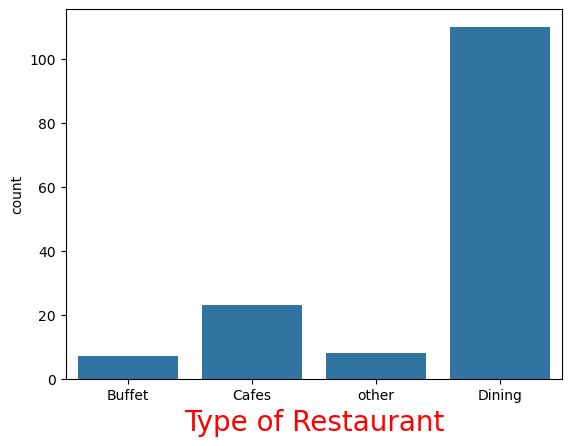

In [22]:
#1 What type of restaurant do the majority of customers order from?

sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("Type of Restaurant",c="red",size=20)

Conclusion - Majority of the Restaurants falls under Dining Category

Text(0, 0.5, 'votes')

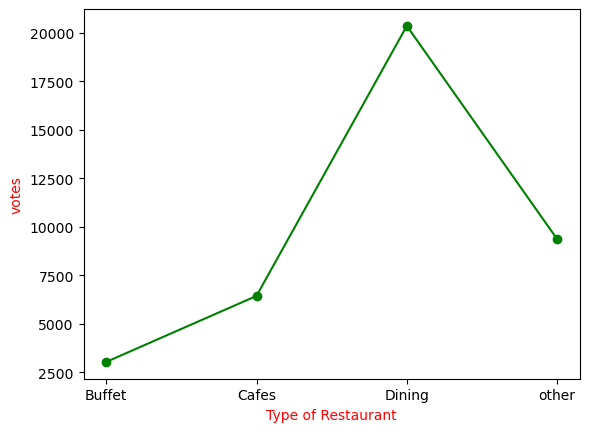

In [24]:
#2 How many votes has each type of restaurants recieved from customers?

grouped_data=dataframe.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes': grouped_data})
plt.plot(result,c='green',marker='o')
plt.xlabel('Type of Restaurant',c='red',size=10)
plt.ylabel('votes',c='red',size=10)

Conclusion - Dining Restaurant has recieved Maximum Votes

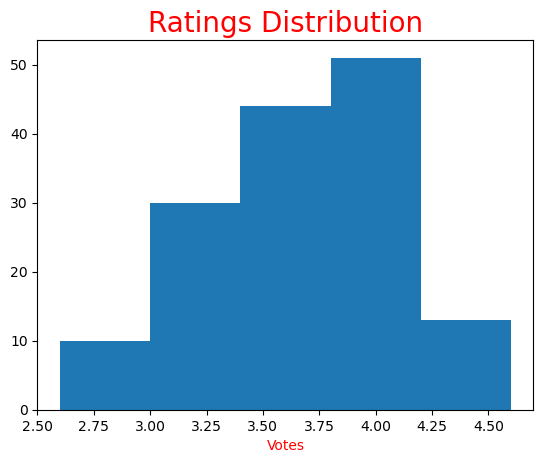

In [26]:
#3 What are the ratings that the majority of restaurants have recieved?

plt.hist(dataframe['rate'],bins=5)
plt.title("Ratings Distribution",c="red",size=20)
plt.xlabel("Votes",c="red")
plt.show()

Conclusion - The majority of Restaurant received Rating from 3.5 to 4

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

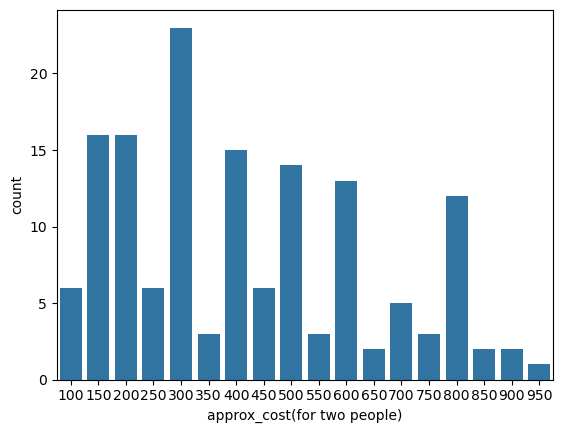

In [28]:
#4 We have observed that most couples order most of their food online. What is their Average spending on each order?
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

Conclusion - The majority of couples prefer Restaurant with an approximate cost of 300 rupees

<Axes: xlabel='online_order', ylabel='rate'>

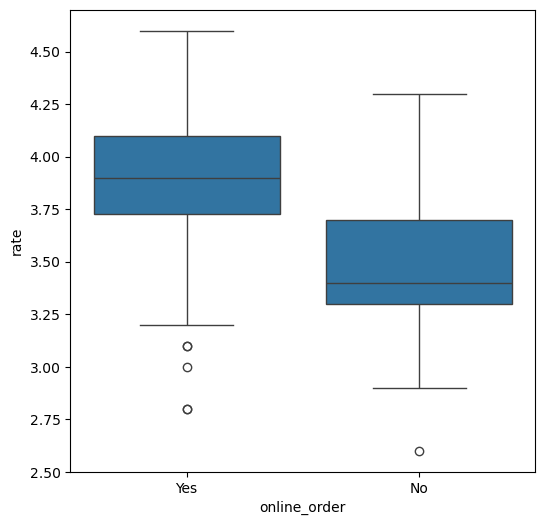

In [30]:
#Which mode (Online or Offline) has recieved the maximum rating?

plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y ='rate',data=dataframe)

Conclusion - Offline order received lower rating as compared to Online order

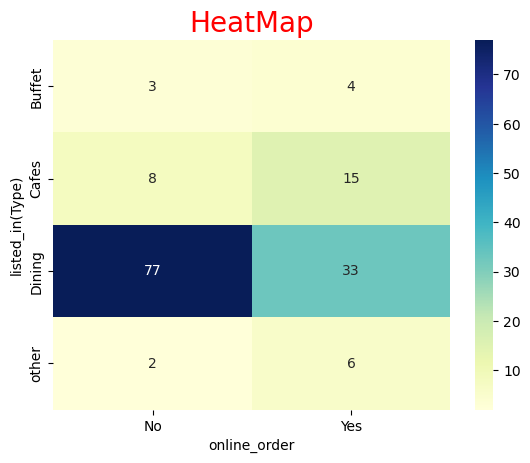

In [32]:
#6 Which type of restaurant recieved more offline orders, so that services can provide customers with some good offers?

pivot_table=dataframe.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table,annot=True,cmap='YlGnBu',fmt='d')
plt.title('HeatMap',c='red',size=20)
plt.xlabel('online_order')
plt.ylabel('listed_in(Type)')
plt.show()

Conclusion -  Dining Restaurants primarily accept Offline orders,whereas cafes primarily receive Online orders.

This suggests that clients preferred to order in person at Restaurants,but prefers Online ordering at cafes.

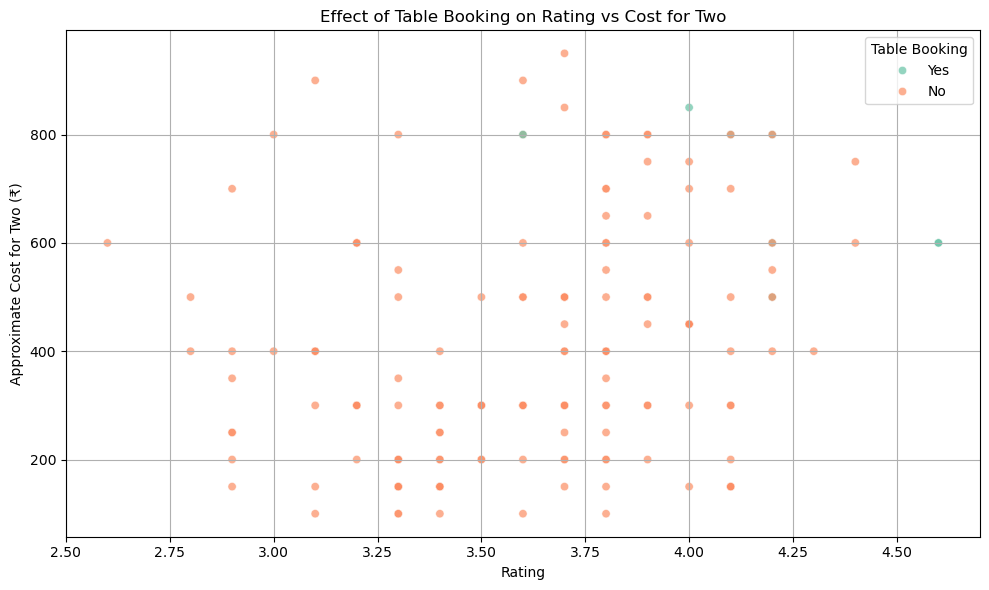

In [34]:
#7 Does availability of table booking affect the cost for two or rating?
# Does availability of table booking affect the cost for two or rating?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dataframe, x='rate', y='approx_cost(for two people)',hue='book_table', palette='Set2', alpha=0.7)
plt.title('Effect of Table Booking on Rating vs Cost for Two')
plt.xlabel('Rating')
plt.ylabel('Approximate Cost for Two (₹)')
plt.grid(True)
plt.legend(title='Table Booking')
plt.tight_layout()
plt.show()


Conclusion - Restaurants offering table booking tend to be costlier, but no strong link to higher ratings is observed.

To predict whether restaurants that offer online ordering but do not provide table booking are profitable (successful) based on customer engagement and service details.

In [36]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt


In [38]:
# Load dataset
df = pd.read_csv("restaurant_analytics.csv")

In [60]:
# Clean 'rate' column (FIXED)
df['rate'] = df['rate'].replace(['NEW', '-'], np.nan)
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [62]:
# Clean cost column
df.dropna(subset=['rate', 'votes', 'approx_cost(for two people)'], inplace=True)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300.0,Buffet
4,Grand Village,No,No,3.8,166,600.0,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100.0,Dining
144,New Indraprasta,No,No,3.3,0,150.0,Dining
145,Anna Kuteera,Yes,No,4.0,771,450.0,Dining
146,Darbar,No,No,3.0,98,800.0,Dining


In [64]:
# Define success (profit proxy): rate > 4.0 AND votes > 200
df['is_successful'] = ((df['rate'] > 4.0) & (df['votes'] > 200)).astype(int)
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),is_successful
0,Jalsa,Yes,Yes,4.1,775,800.0,Buffet,1
1,Spice Elephant,Yes,No,4.1,787,800.0,Buffet,1
2,San Churro Cafe,Yes,No,3.8,918,800.0,Buffet,0
3,Addhuri Udupi Bhojana,No,No,3.7,88,300.0,Buffet,0
4,Grand Village,No,No,3.8,166,600.0,Buffet,0
...,...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100.0,Dining,0
144,New Indraprasta,No,No,3.3,0,150.0,Dining,0
145,Anna Kuteera,Yes,No,4.0,771,450.0,Dining,0
146,Darbar,No,No,3.0,98,800.0,Dining,0


In [66]:
# Encode categorical variables
le = LabelEncoder()
df['online_order'] = le.fit_transform(df['online_order'])  # Yes=1, No=0
df['book_table'] = le.fit_transform(df['book_table'])
df['listed_in(type)'] = le.fit_transform(df['listed_in(type)'])
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),is_successful
0,Jalsa,1,1,4.1,775,800.0,0,1
1,Spice Elephant,1,0,4.1,787,800.0,0,1
2,San Churro Cafe,1,0,3.8,918,800.0,0,0
3,Addhuri Udupi Bhojana,0,0,3.7,88,300.0,0,0
4,Grand Village,0,0,3.8,166,600.0,0,0
...,...,...,...,...,...,...,...,...
143,Melting Melodies,0,0,3.3,0,100.0,2,0
144,New Indraprasta,0,0,3.3,0,150.0,2,0
145,Anna Kuteera,1,0,4.0,771,450.0,2,0
146,Darbar,0,0,3.0,98,800.0,2,0


In [68]:
# Filter for restaurants WITH online_order AND WITHOUT book_table
df_filtered = df[(df['online_order'] == 1) & (df['book_table'] == 0)]

# Features and target
features = ['approx_cost(for two people)', 'listed_in(type)']
X = df_filtered[features]
y = df_filtered['is_successful']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.70      0.82        10
           1       0.25      1.00      0.40         1

    accuracy                           0.73        11
   macro avg       0.62      0.85      0.61        11
weighted avg       0.93      0.73      0.79        11

Confusion Matrix:
 [[7 3]
 [0 1]]


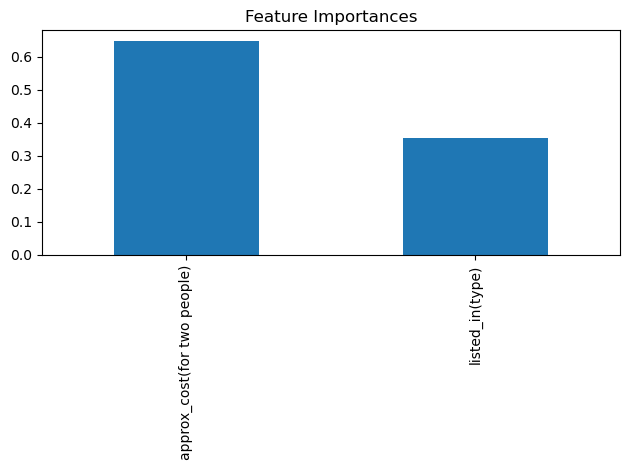

In [70]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values(ascending=False).plot(kind='bar', title='Feature Importances')
plt.tight_layout()
plt.show()